In [53]:
# import ecmwf.data as ecdata
from ecmwf.opendata import Client
import metview as mv
import xarray as xr
import pandas as pd
import pygrib as pg
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

Matplotlib is building the font cache; this may take a moment.


In [2]:
parameters = ['100u', '100v', 'ssrd',  '2t']
filename = './weather-data/test.grib2'
client = Client("ecmwf", beta=True)
client.retrieve(
 date=0,
 time=0,
 step=24,
 stream="enfo",
 type=['cf', 'pf'],
 levtype="sfc",
 param=parameters,
 target=filename
)

In [43]:
grb = pg.open(filename)

In [ ]:
for msg in grb:
    print(msg)  # Print information about the message

Highest temperatures in Spain

In [51]:
msg = grb.select(name='2 metre temperature', level=2)[0]
# 100 metre U wind component
data = msg.values
lats, lons = msg.latlons()
lat_min, lat_max = 37, 41
lon_min, lon_max = -6, -3
# Create a boolean mask to filter the data within the specified region
mask = (lats >= lat_min) & (lats <= lat_max) & (lons >= lon_min) & (lons <= lon_max)

# Apply the mask to the data and coordinates
data_spain = data[mask]
lats_spain = lats[mask]
lons_spain = lons[mask]

df_spain = pd.DataFrame({'temperature': data_spain, 'latitude': lats_spain, 'longitude': lons_spain})
print(df_spain.head(5))


   temperature  latitude  longitude
0   279.590912      41.0      -6.00
1   278.653412      41.0      -5.75
2   278.372162      41.0      -5.50
3   278.340912      41.0      -5.25
4   278.153412      41.0      -5.00


In [80]:
highestTemp = df_spain.loc[df_spain['temperature'].idxmax()]

print(highestTemp)

temperature    284.403412
latitude        37.750000
longitude       -5.500000
Name: 171, dtype: float64


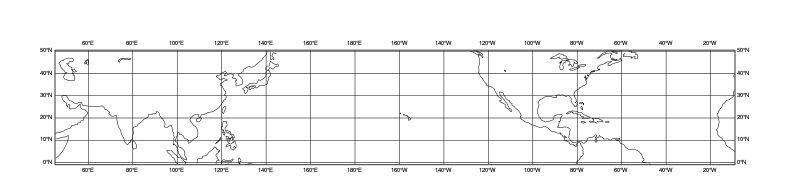

In [ ]:
# plt.figure(figsize=(10, 8))
# ax = plt.axes(projection=ccrs.PlateCarree())

# plt.figure(figsize=(10, 8))
# ax = plt.axes(projection=ccrs.PlateCarree())
# ax.set_extent([-10, 5, 36, 44])  # Set map extent for Spain

# # Plot the point with the highest temperature
# ax.scatter(highestTemp.longitude, highestTemp.latitude, color='red', marker='o')

# plt.show()

north = highestTemp.latitude + 2
south = highestTemp.latitude - 2
east = highestTemp.longitude + 2
west = highestTemp.longitude - 2


view = mv.geoview(
    map_area_definition = "corners",
    area                = [north, south, east, west]
    )
coloured_markers = mv.msymb(
    legend                                 = "on",
    symbol_type                            = "marker",
    symbol_table_mode                      = "advanced",
    symbol_advanced_table_max_level_colour = "red",
    symbol_advanced_table_min_level_colour = "RGB(1, 0.8, 0.8)",
    symbol_advanced_table_height_list      = 0.8
    )
mv.plot(view, [{'latitude': highestTemp.latitude,'longitude': highestTemp.longitude,'value': highestTemp.temperature}], coloured_markers)

Wind speed calculation

In [ ]:
sp = mv.sqrt(u100*u100 + v100*v100)
sp = mv.grib_set_long(sp, ['paramId', 10])
mv.grib_get(sp, ['shortName', 'paramId','level', 'step'])

In [ ]:
mv.setoutput('jupyter')
mv.plot(sp, mv.mcont(contour_automatic_setting='ecmwf', legend='on'))

In [13]:
data_esuite_to_simple = mv.grib_set(data_osuite, ["packingType", "grid_simple"], repack=True)


In [14]:
mv.grib_get(data_esuite_to_simple, ['packingType'])
print(mv.minvalue(data_esuite_to_simple[0]), mv.minvalue(data_osuite[0]))

0.0 0.0


In [16]:
mv.maxvalue(mv.abs(data_esuite_to_simple[0] - data_osuite[0]))

0.0